# An end-to-end ML project: wine quality

The workbook from the start of the course, which walks through the steps of a whole project on one small
problem. Most of the individual techniques get their own notebook later in this repo; this one is about
how the pieces fit together.

**The scenario:** a wine company wants to predict wine quality from physicochemical measurements, so it
can replace an expensive quality sensor (or tasting panel).

The steps:

1. look at the big picture
2. get the data
3. explore and visualise it
4. prepare it for ML algorithms
5. select and train a model
6. fine-tune it
7. present the solution
8. launch, monitor and maintain

A few things from the course notes worth keeping in mind:

* ML is usually a small piece of a bigger project. Here the model is one part of the manufacturing process.
* Typically only 10-15% of the time goes into the ML itself. Much more goes into getting and cleaning the
  data and acting on the model's output.
* It needs close work with domain experts, product managers and engineering teams.

## Step 1: the big picture

### Frame the problem

* What's the input and output? Input: 11 chemical measurements of a wine. Output: a quality score.
* What's the business objective, and how will the company use the model? That decides which mistakes
  are expensive and how good the model needs to be.
* What does the current solution look like? It's the baseline to beat.

Design questions:

* supervised, unsupervised or reinforcement learning? **Supervised**: there are labelled examples.
* classification or regression? Quality is an integer from 0 to 10, so either works. Treating it as
  **regression** keeps the ordering (predicting 6 for a 7 is better than predicting 3), so that's used here.
* one output or several? One.
* batch or online learning? Batch: the data is small and doesn't arrive continuously.

### Choose a performance measure

* regression: mean squared error (MSE) or mean absolute error (MAE)
* classification: precision, recall, F1, accuracy

MSE is used here, as in the course.

### Check the assumptions

Write down the assumptions (for example, that the downstream system wants a number and not a category)
and get them confirmed with whoever will use the output, before writing any code.

## Step 2: get the data

Red wine quality from the UCI repository (the same data is on
[Kaggle](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009), where it's
comma-separated instead of `;`).

The course spent a while on ways of getting a CSV into Colab: the Files pane, `files.upload()`, or
mounting Google Drive:

```python
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/winequality-red.csv')
```

Reading straight from the URL avoids all of that.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data.shape

(1599, 12)

### What the features mean

| feature | |
|---|---|
| fixed acidity | most acids in wine; they don't evaporate readily |
| volatile acidity | acetic acid; too much gives a vinegar taste |
| citric acid | small amounts add freshness and flavour |
| residual sugar | sugar left after fermentation; above 45 g/l counts as sweet |
| chlorides | salt |
| free sulfur dioxide | free SO2, prevents microbial growth and oxidation |
| total sulfur dioxide | free + bound SO2; noticeable in taste above about 50 ppm |
| density | close to water, depends on alcohol and sugar |
| pH | acidity on the pH scale, most wines 3-4 |
| sulphates | additive contributing to SO2 levels |
| alcohol | % by volume |
| **quality** | score between 0 and 10 (the label) |

In [4]:
feature_list = data.columns[:-1].tolist()
print("features:", feature_list)
print("label: quality")

features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
label: quality


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


1599 rows (tiny by ML standards), 11 numeric features, an integer label, no missing values.

In [6]:
data.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


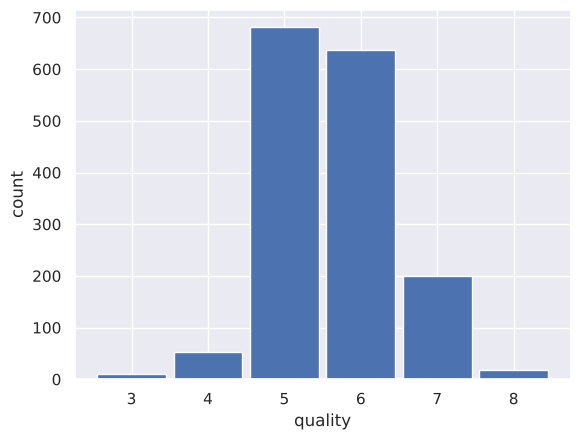

In [7]:
print(data['quality'].value_counts().sort_index())
data['quality'].hist(bins=np.arange(2.5, 9.5, 1), rwidth=0.9)
plt.xlabel('quality'); plt.ylabel('count')
plt.show()

Quality only goes from 3 to 8 here, and most wines are a 5 or 6. Very few are poor or excellent, which
will make those hard to predict.

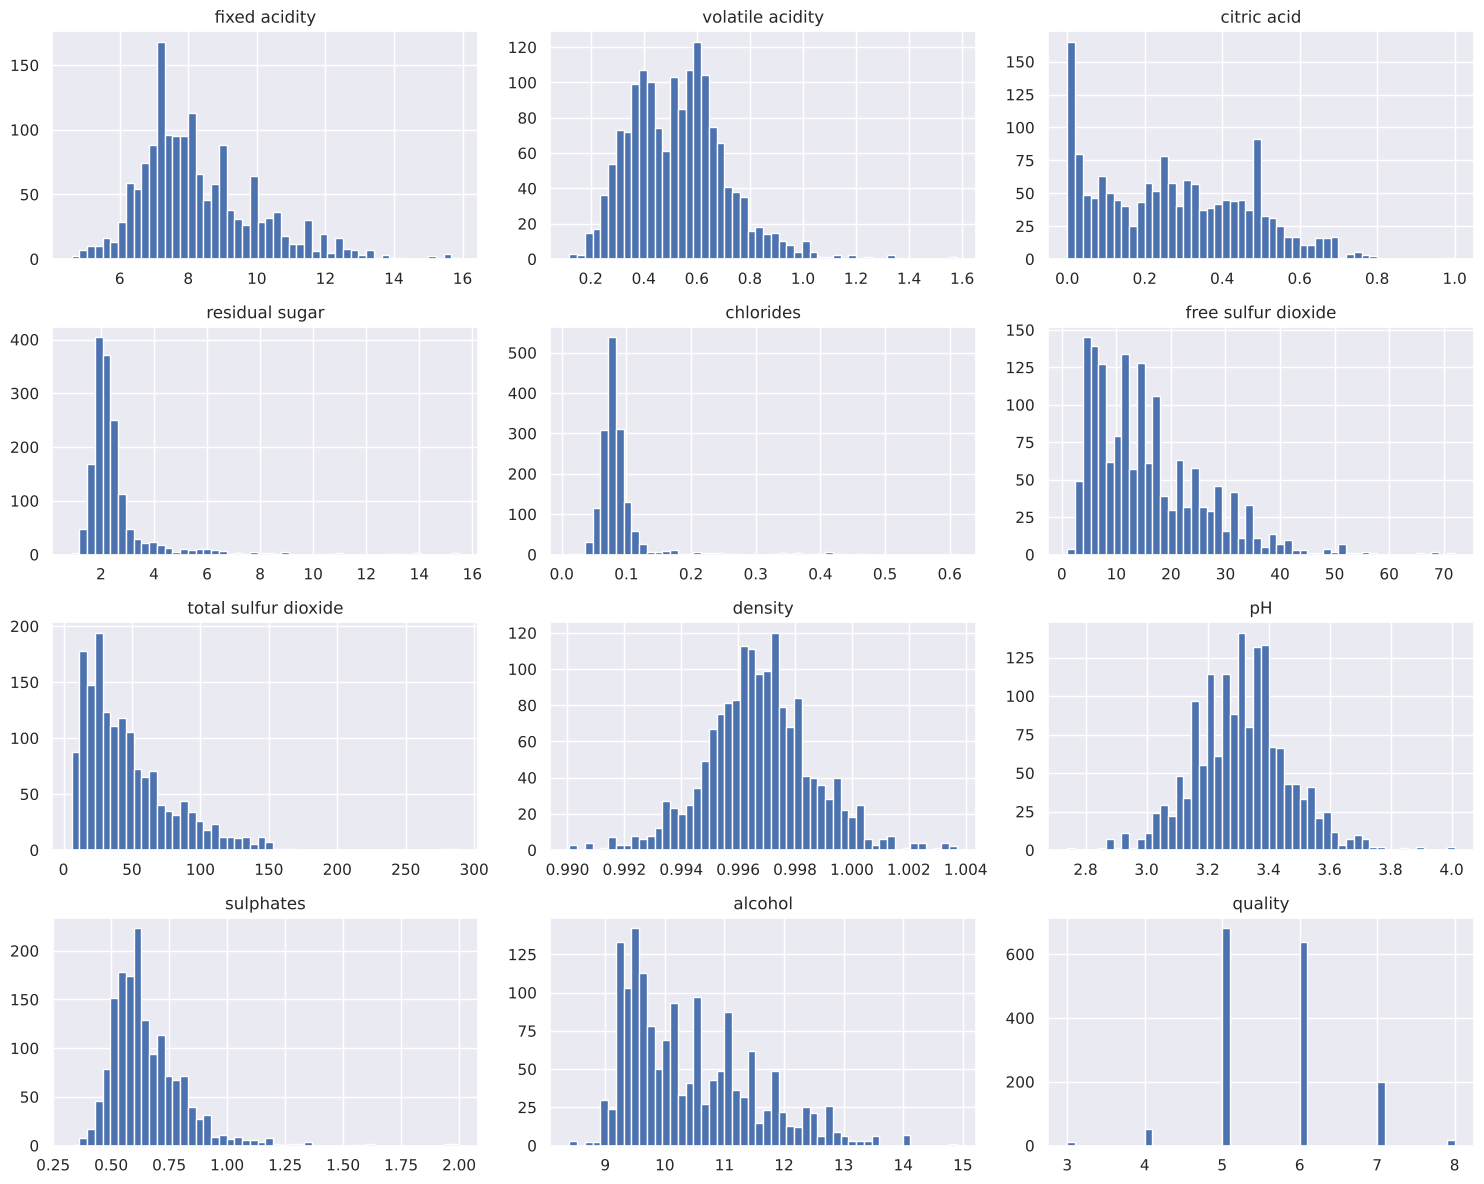

In [8]:
data.hist(bins=50, figsize=(15, 12))
plt.tight_layout()
plt.show()

* The features are on very different scales.
* Some are right-skewed with long tails (residual sugar, chlorides, free and total SO2).
* Some have more than one peak (volatile acidity, citric acid).

### Set aside a test set, now

Before looking any further. If you explore all the data, you start noticing patterns in what will become
the test set, and model choices quietly adapt to them. That's **data snooping bias**, and the test score
ends up optimistic.

A split by hand, to see what it does:

In [9]:
def split_train_test(data, test_ratio, seed=42):
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(len(data))
    n_test = int(len(data) * test_ratio)
    return data.iloc[shuffled[n_test:]], data.iloc[shuffled[:n_test]]

train_set, test_set = split_train_test(data, 0.2)
print(len(train_set), "train,", len(test_set), "test")

1280 train, 319 test


Setting the seed makes the split the same every run. (The course called `np.random.seed()` inside the
function, which also changes the global random state for everything that runs afterwards. A local
`RandomState` doesn't have that side effect.)

`train_test_split` does the same thing. `random_state` fixes the split, and `stratify` keeps the class
proportions equal in both parts:

In [10]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

random_train, random_test = train_test_split(data, test_size=0.2, random_state=42)
strat_train_set, strat_test_set = train_test_split(data, test_size=0.2, random_state=42,
                                                   stratify=data['quality'])

`StratifiedShuffleSplit` is the class version, useful when you want several stratified splits:

In [11]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(sss.split(data, data["quality"]))
print(len(train_index), len(test_index))

1279 320


### Why stratify?

Compare the class proportions in the test set with the full data:

In [12]:
overall = data['quality'].value_counts(normalize=True)
comparison = pd.DataFrame({
    'overall': overall,
    'stratified': strat_test_set['quality'].value_counts(normalize=True),
    'random': random_test['quality'].value_counts(normalize=True),
}).sort_index()
comparison['stratified error %'] = 100 * (comparison['stratified'] - comparison['overall']) / comparison['overall']
comparison['random error %'] = 100 * (comparison['random'] - comparison['overall']) / comparison['overall']
comparison.round(3)

,overall,stratified,random,stratified error %,random error %
quality,,,,,
3,0.006,0.006,0.003,-0.062,-50.031
4,0.033,0.034,0.031,3.709,-5.719
5,0.426,0.425,0.406,-0.209,-4.612
6,0.399,0.400,0.412,0.251,3.384
7,0.124,0.125,0.131,0.440,5.462
8,0.011,0.009,0.016,-16.719,38.802


The stratified split matches the overall distribution almost exactly in every class. The random split is
off by a lot in the rare classes (3 and 8), where a handful of wines more or less is a big percentage.
The stratified split is used from here on.

## Step 3: explore the training data

Only the training set. (The course made `exploration_set = data.copy()`, i.e. explored *all* the data
straight after explaining why not to.)

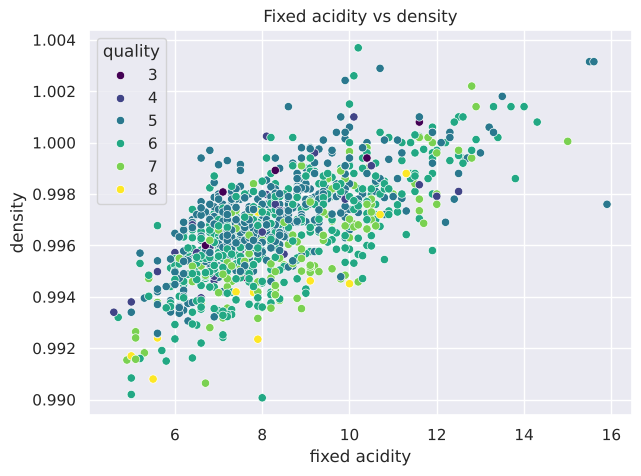

In [13]:
exploration_set = strat_train_set.copy()

plt.figure(figsize=(7, 5))
sns.scatterplot(x='fixed acidity', y='density', hue='quality', data=exploration_set, palette='viridis')
plt.title('Fixed acidity vs density')
plt.show()

### Correlations

Pearson correlation goes from -1 to +1 and only measures *linear* relationships. For monotonic but
non-linear relationships, rank (Spearman) correlation is better.

In [14]:
corr_matrix = exploration_set.corr()
corr_matrix['quality'].drop('quality').sort_values().round(3)

volatile acidity       -0.383
total sulfur dioxide   -0.195
density                -0.193
chlorides              -0.120
pH                     -0.052
free sulfur dioxide    -0.048
residual sugar          0.004
fixed acidity           0.108
citric acid             0.211
sulphates               0.228
alcohol                 0.481
Name: quality, dtype: float64

Quality is most positively correlated with **alcohol** (about 0.48) and most negatively with **volatile
acidity** (about -0.39).

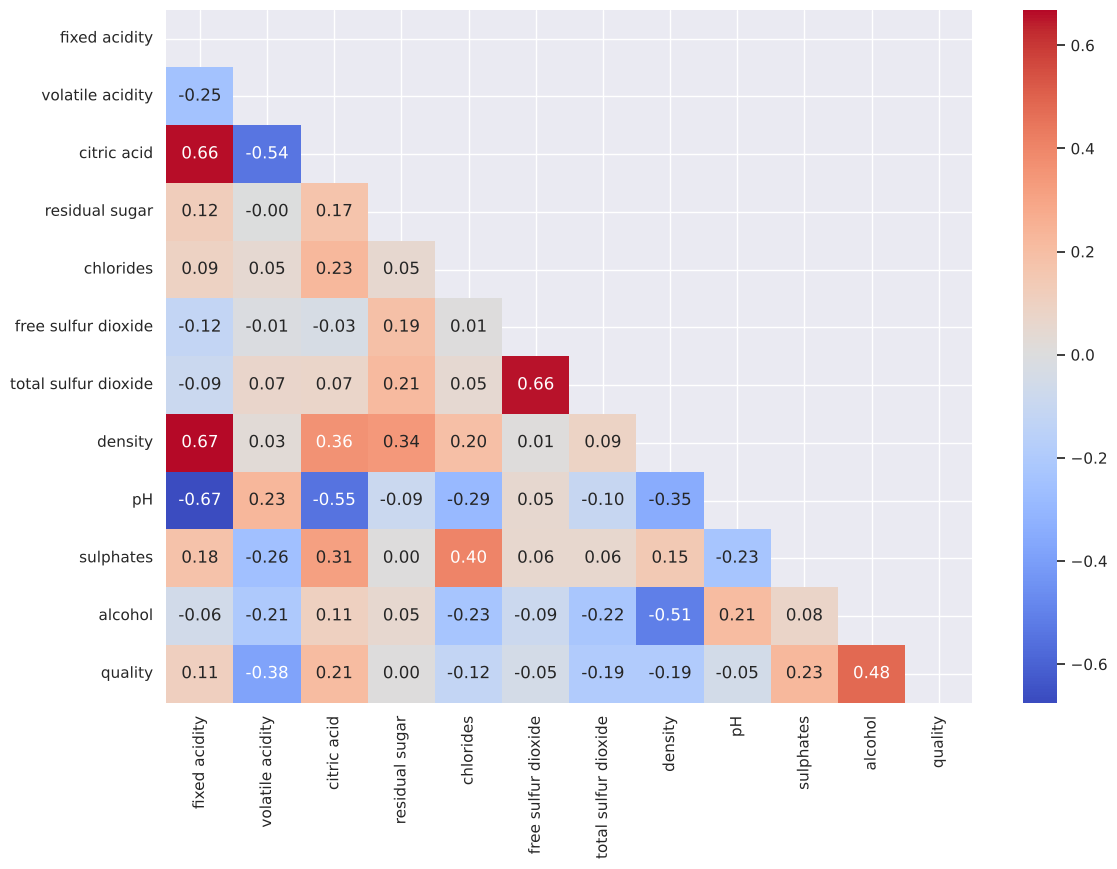

In [15]:
plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask, cmap='coolwarm', center=0)
plt.show()

Among the features: fixed acidity is strongly positively correlated with citric acid and density, and
negatively with pH (more acid, lower pH, as it should be). Free and total SO2 go together.

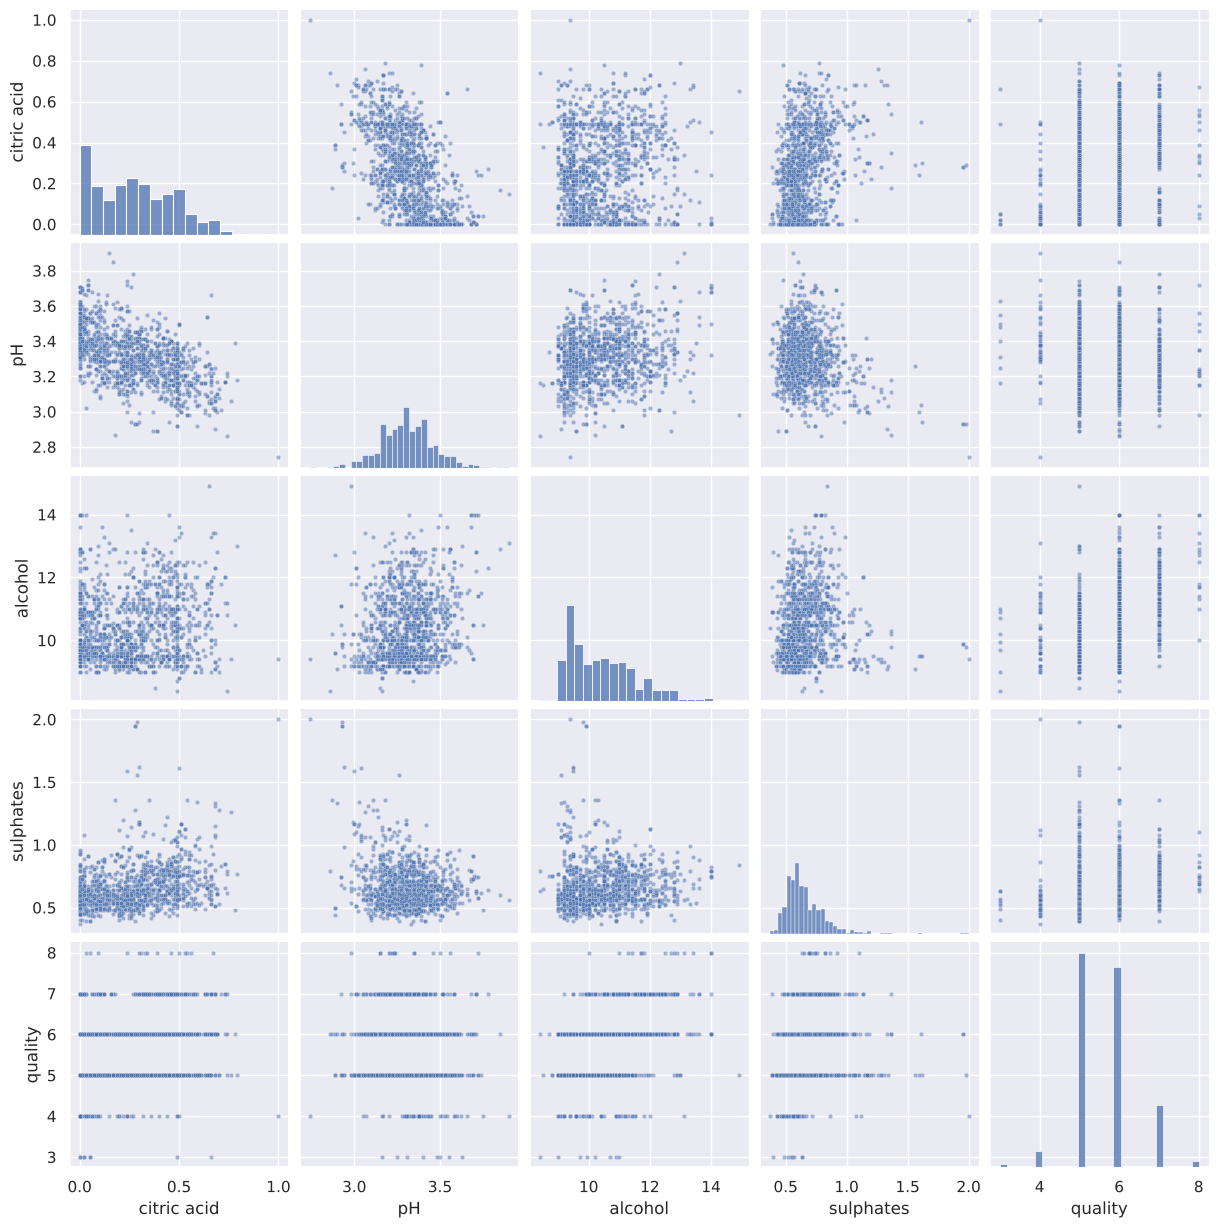

In [16]:
attribute_list = ['citric acid', 'pH', 'alcohol', 'sulphates', 'quality']
sns.pairplot(exploration_set[attribute_list], plot_kws={'s': 10, 'alpha': 0.5})
plt.show()

Exploration doesn't need to be exhaustive. The point is a quick feel for the features and their
relationship with the label. It's iterative: after building a model you often come back here with new
questions. Derived features (ratios, products) can be explored the same way.

## Step 4: prepare the data

Typical steps:

1. separate features and labels
2. handle missing values and outliers
3. scale features
4. transform skewed distributions (log, square root)

All learned from the **training data** and then applied to the test data. Never fitted on the full dataset.

In [17]:
wine_features = strat_train_set.drop("quality", axis=1)
wine_labels = strat_train_set['quality'].copy()
wine_features_test = strat_test_set.drop("quality", axis=1)
wine_labels_test = strat_test_set['quality'].copy()

wine_features.isna().sum().sum()

np.int64(0)

No missing values. If there were, the options are dropping rows (`dropna`), dropping the column, or
imputing. `SimpleImputer` with the median, for example:

In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median").fit(wine_features)
pd.DataFrame({'imputer': imputer.statistics_, 'pandas median': wine_features.median()})

,imputer,pandas median
fixed acidity,7.90000,7.90000
volatile acidity,0.52000,0.52000
citric acid,0.26000,0.26000
residual sugar,2.20000,2.20000
chlorides,0.08000,0.08000
free sulfur dioxide,14.00000,14.00000
total sulfur dioxide,39.00000,39.00000
density,0.99675,0.99675
pH,3.31000,3.31000
sulphates,0.62000,0.62000


There are no categorical features in this data. If there were (say, a `region` column), they'd need
`OneHotEncoder` (or `OrdinalEncoder` for ordered categories). With very many categories, one-hot creates a
lot of columns, and alternatives are grouping rare categories or learned embeddings.

### A preprocessing pipeline

Impute, then standardise:

In [19]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

transform_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])
wine_features_tr = transform_pipeline.fit_transform(wine_features)
wine_features_test_tr = transform_pipeline.transform(wine_features_test)

Each step is a `(name, estimator)` pair. Names must be unique and can't contain `__` (that's the
separator used for parameter names, e.g. `std_scaler__with_mean`). The pipeline exposes the methods of its
last step, so a pipeline ending in a transformer has `fit_transform`, and one ending in a model has
`predict`.

For mixed data, `ColumnTransformer` applies different pipelines to different columns:

```python
from sklearn.compose import ColumnTransformer
full_pipeline = ColumnTransformer([
    ("num", transform_pipeline, numeric_columns),
    ("cat", OneHotEncoder(), ["region"]),
])
```

## Step 5: select and train a model

Start with something quick as a baseline.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg = LinearRegression().fit(wine_features_tr, wine_labels)
print(f"train MSE: {mean_squared_error(wine_labels, lin_reg.predict(wine_features_tr)):.3f}")
print(f"test MSE:  {mean_squared_error(wine_labels_test, lin_reg.predict(wine_features_test_tr)):.3f}")

train MSE: 0.421
test MSE:  0.406


(Checking the test score at this stage is only to see the numbers. In a real project the test set stays
untouched until the very end, and model comparison happens with cross validation, below.)

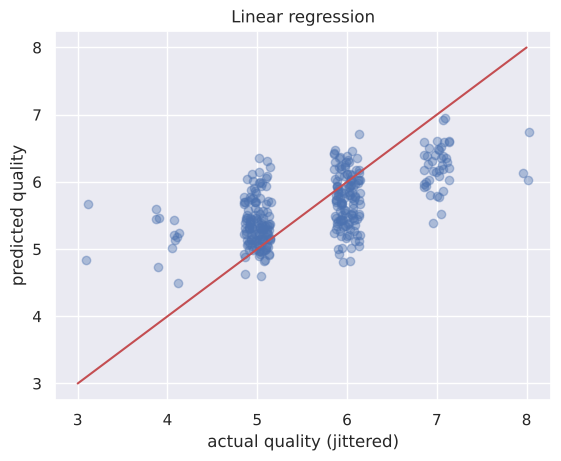

In [21]:
def plot_predictions(model, title):
    pred = model.predict(wine_features_test_tr)
    jitter = np.random.RandomState(0).uniform(-0.15, 0.15, len(pred))
    plt.scatter(wine_labels_test + jitter, pred, alpha=0.4)
    plt.plot([3, 8], [3, 8], 'r-')
    plt.xlabel('actual quality (jittered)'); plt.ylabel('predicted quality'); plt.title(title)
    plt.show()

plot_predictions(lin_reg, 'Linear regression')

Predictions are squeezed towards the middle: the model never predicts below about 4.5 or above about
7, so it gets the worst and the best wines wrong. Typical when most of the training data sits at 5 and 6.

A decision tree:

In [22]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42).fit(wine_features_tr, wine_labels)
print(f"train MSE: {mean_squared_error(wine_labels, tree_reg.predict(wine_features_tr)):.3f}")
print(f"test MSE:  {mean_squared_error(wine_labels_test, tree_reg.predict(wine_features_test_tr)):.3f}")

train MSE: 0.000
test MSE:  0.525


Zero training error, much worse test error: the tree memorised the training set (overfitting). The code is
the same as for linear regression apart from the class name; that's the consistent sklearn API at work.

### Cross validation

A more reliable comparison than one train/test split.

In [23]:
from sklearn.model_selection import cross_val_score

def cv_mse(model):
    scores = -cross_val_score(model, wine_features_tr, wine_labels, scoring="neg_mean_squared_error", cv=10)
    print(f"{type(model).__name__:24s} MSE {scores.mean():.3f} +/- {scores.std():.3f}")
    return scores

lin_scores = cv_mse(LinearRegression())
tree_scores = cv_mse(DecisionTreeRegressor(random_state=42))

LinearRegression         MSE 0.432 +/- 0.084


DecisionTreeRegressor    MSE 0.670 +/- 0.162


Linear regression has a lower average error and a smaller spread between folds.

A random forest (an average of many trees trained on random subsets, covered in the ensemble notebooks):

In [24]:
from sklearn.ensemble import RandomForestRegressor

forest_scores = cv_mse(RandomForestRegressor(random_state=42, n_jobs=-1))

RandomForestRegressor    MSE 0.352 +/- 0.077


Best of the three. Normally you'd try a handful of model types quickly like this, without tuning, and
shortlist the promising ones.

| diagnosis | remedies |
|---|---|
| underfitting | a more powerful model, fewer constraints / less regularisation, better features |
| overfitting | more data, a simpler model, more constraints / regularisation |

## Step 6: fine-tune

`GridSearchCV` tries every combination of the given hyperparameter values with cross validation. A list
of dicts means separate grids:

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5,
                           scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search.fit(wine_features_tr, wine_labels)
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

3 x 4 + 2 x 3 = 18 combinations, each trained 5 times: 90 fits.

In [26]:
cvres = pd.DataFrame(grid_search.cv_results_)
cvres['mean MSE'] = -cvres['mean_test_score']
cvres[['params', 'mean MSE']].sort_values('mean MSE').head(8)

,params,mean MSE
5,"{'max_features': 4, 'n_estimators': 30}",0.357102
2,"{'max_features': 2, 'n_estimators': 30}",0.360557
11,"{'max_features': 8, 'n_estimators': 30}",0.363182
8,"{'max_features': 6, 'n_estimators': 30}",0.371812
17,"{'bootstrap': False, 'max_features': 4, 'n_est...",0.377081
4,"{'max_features': 4, 'n_estimators': 10}",0.381012
10,"{'max_features': 8, 'n_estimators': 10}",0.385677
13,"{'bootstrap': False, 'max_features': 2, 'n_est...",0.386012


More trees help, and very few trees (3) are clearly worse. The best combination here (0.357) is actually no
better than the untuned forest above (0.352), because the grid stops at 30 trees and the default is 100.
The grid from the course was designed when the default was 10 trees. With `refit=True` (the default) the best
combination is retrained on the whole training set and available as `best_estimator_`.

`RandomizedSearchCV` samples a fixed number of combinations instead of trying all of them, which keeps the
cost under control when the grid is large.

### What the model learned

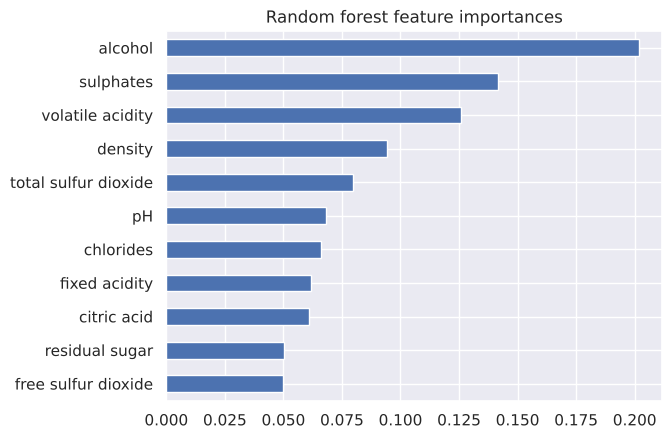

In [27]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=feature_list).sort_values()
importances.plot.barh()
plt.title('Random forest feature importances')
plt.show()

Alcohol, sulphates and volatile acidity matter most, in line with the correlations. Low-importance features
are candidates for dropping, and looking at the largest errors often suggests what's missing.

### Final evaluation on the test set

test MSE: 0.327


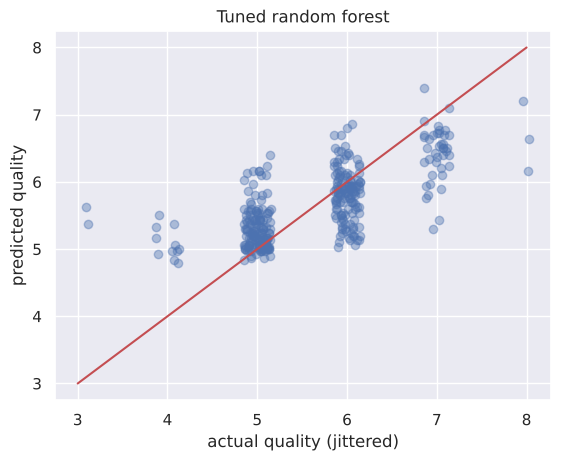

In [28]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(wine_features_test_tr)
print(f"test MSE: {mean_squared_error(wine_labels_test, final_predictions):.3f}")
plot_predictions(final_model, 'Tuned random forest')

A 95% confidence interval for the test MSE, using the t distribution over the per-wine squared errors:

In [29]:
from scipy import stats

squared_errors = (final_predictions - wine_labels_test) ** 2
stats.t.interval(0.95, len(squared_errors) - 1, loc=squared_errors.mean(), scale=stats.sem(squared_errors))

(np.float64(0.2533322827904926), np.float64(0.39970938387617405))

For context, a model that always predicts the training mean:

In [30]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor().fit(wine_features_tr, wine_labels)
print(f"baseline test MSE: {mean_squared_error(wine_labels_test, dummy.predict(wine_features_test_tr)):.3f}")

baseline test MSE: 0.645


## Step 7: present the solution

Before launch: present what was learned, which assumptions were made and what the system can't do;
document everything with clear visualisations. Even a model that doesn't beat human experts can be worth
launching if it frees up their time.

## Step 8: launch, monitor, maintain

* **launch**: connect the input sources, write tests
* **monitor**: outages, drops in model performance (the incoming data can drift), sample predictions for
  human review, data quality checks
* **maintain**: retrain on fresh data regularly and roll out new versions safely

One practical detail: everything learned during training (scaler, imputer, model) has to be saved and
reused together, which is the main reason to keep the preprocessing and the model in a single `Pipeline`
and save that with `joblib.dump`.

In [31]:
import joblib, os, tempfile

full_model = make_pipeline(transform_pipeline, final_model)
path = os.path.join(tempfile.gettempdir(), 'wine_model.joblib')
joblib.dump(full_model, path)
reloaded = joblib.load(path)
reloaded.predict(wine_features_test.iloc[:3]), wine_labels_test.iloc[:3].to_numpy()

(array([6.43333333, 5.43333333, 4.96666667]), array([6, 5, 5]))

The reloaded pipeline takes raw feature rows and does the imputation and scaling itself.